In [27]:
import torch
import torch.nn as nn

In [28]:
class MLP(nn.Module):
    def __init__(self, input_dim, h1, h2, h3, output_dim):
        super().__init__()

        self.Wh1 = nn.Parameter(torch.randn(input_dim, h1))
        self.bh1 = nn.Parameter(torch.zeros(h1))

        self.Wh2 = nn.Parameter(torch.randn(h1, h2))
        self.bh2 = nn.Parameter(torch.zeros(h2))

        self.Wh3 = nn.Parameter(torch.randn(h2, h3))
        self.bh3 = nn.Parameter(torch.zeros(h3))

        self.Wo  = nn.Parameter(torch.randn(h3, output_dim))
        self.bo  = nn.Parameter(torch.zeros(output_dim))

        self.relu = nn.ReLU()

    def forward(self, x):
        h1 = self.relu(x @ self.Wh1 + self.bh1)
        h2 = self.relu(h1 @ self.Wh2 + self.bh2)
        h3 = self.relu(h2 @ self.Wh3 + self.bh3)
        out = h3 @ self.Wo + self.bo
        return out
    
    def loss(self, y_true, y_pred):
        N = y_true.shape[0]
        return torch.sum((y_true - y_pred) ** 2) / N

    def zero_grad(self):
        for p in self.parameters:
            if p.grad is not None:
                p.grad.zero_()
        
    def step(self, lr):
        for p in self.parameters:
            p.data -= lr * p.grad

    

In [29]:
class MLP(nn.Module):
    def __init__(self, input_dim, h1, h2, h3, output_dim):
        super().__init__()

        # Use proper weight initialization (Xavier/He) to prevent exploding gradients
        self.Wh1 = nn.Parameter(torch.randn(input_dim, h1) * (2.0 / input_dim) ** 0.5)
        self.bh1 = nn.Parameter(torch.zeros(h1))

        self.Wh2 = nn.Parameter(torch.randn(h1, h2) * (2.0 / h1) ** 0.5)
        self.bh2 = nn.Parameter(torch.zeros(h2))

        self.Wh3 = nn.Parameter(torch.randn(h2, h3) * (2.0 / h2) ** 0.5)
        self.bh3 = nn.Parameter(torch.zeros(h3))

        self.Wo  = nn.Parameter(torch.randn(h3, output_dim) * (2.0 / h3) ** 0.5)
        self.bo  = nn.Parameter(torch.zeros(output_dim))

        self.relu = nn.ReLU()

    def forward(self, x):
        h1 = self.relu(x @ self.Wh1 + self.bh1)
        h2 = self.relu(h1 @ self.Wh2 + self.bh2)
        h3 = self.relu(h2 @ self.Wh3 + self.bh3)
        out = h3 @ self.Wo + self.bo
        return out
    
    def loss(self, y_true, y_pred):
        N = y_true.shape[0]
        return torch.sum((y_true - y_pred) ** 2) / N

    def zero_grad(self):
        for p in self.parameters():
            if p.grad is not None:
                p.grad.zero_()
        
    def step(self, lr):
        # update params without tracking in autograd
        with torch.no_grad():
            for p in self.parameters():
                if p.grad is not None:
                    p.data -= lr * p.grad

In [30]:
import pandas as pd

df = pd.read_csv('housing.csv')

binary_cols = [
    "mainroad","guestroom","basement","hotwaterheating",
    "airconditioning","prefarea"
]

for col in binary_cols:
    df[col] = df[col].map({'yes': 1, 'no': 0})


In [31]:
df = pd.get_dummies(df, columns=["furnishingstatus"], drop_first=True)


In [32]:
print(df.dtypes)

price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
guestroom                          int64
basement                           int64
hotwaterheating                    int64
airconditioning                    int64
parking                            int64
prefarea                           int64
furnishingstatus_semi-furnished     bool
furnishingstatus_unfurnished        bool
dtype: object


In [33]:
df = df.astype({ 
    "furnishingstatus_semi-furnished": int,
    "furnishingstatus_unfurnished": int
})


In [34]:
y = torch.tensor(df["price"].values, dtype=torch.float32).view(-1, 1)
X = torch.tensor(df.drop("price", axis=1).values, dtype=torch.float32)

In [35]:
# Normalize input data to prevent gradient explosion
X_mean = X.mean(dim=0)
X_std = X.std(dim=0)
X_norm = (X - X_mean) / (X_std + 1e-7)

y_mean = y.mean()
y_std = y.std()
y_norm = (y - y_mean) / (y_std + 1e-7)

model = MLP(X_norm.shape[1], 64, 32, 16, 1)

lr = 0.001  # Conservative learning rate
loss_history = []

for step in range(500):
    # Decay learning rate after 200 steps
    if step > 200:
        lr = 0.0001

    y_pred = model.forward(X_norm)
    loss = model.loss(y_norm, y_pred)
    loss_history.append(loss.item())

    model.zero_grad()
    loss.backward()
    
    # Gradient clipping to prevent explosion
    for p in model.parameters():
        if p.grad is not None:
            p.grad.clamp_(-1.0, 1.0)
    
    model.step(lr)

    if step % 50 == 0:
        print(f"Step {step}, Loss: {loss.item():.6f}")

Step 0, Loss: 2.363573
Step 50, Loss: 0.844573
Step 100, Loss: 0.613664
Step 50, Loss: 0.844573
Step 100, Loss: 0.613664
Step 150, Loss: 0.519920
Step 150, Loss: 0.519920
Step 200, Loss: 0.471163
Step 250, Loss: 0.466903
Step 200, Loss: 0.471163
Step 250, Loss: 0.466903
Step 300, Loss: 0.463479
Step 350, Loss: 0.460178
Step 300, Loss: 0.463479
Step 350, Loss: 0.460178
Step 400, Loss: 0.456989
Step 450, Loss: 0.453921
Step 400, Loss: 0.456989
Step 450, Loss: 0.453921


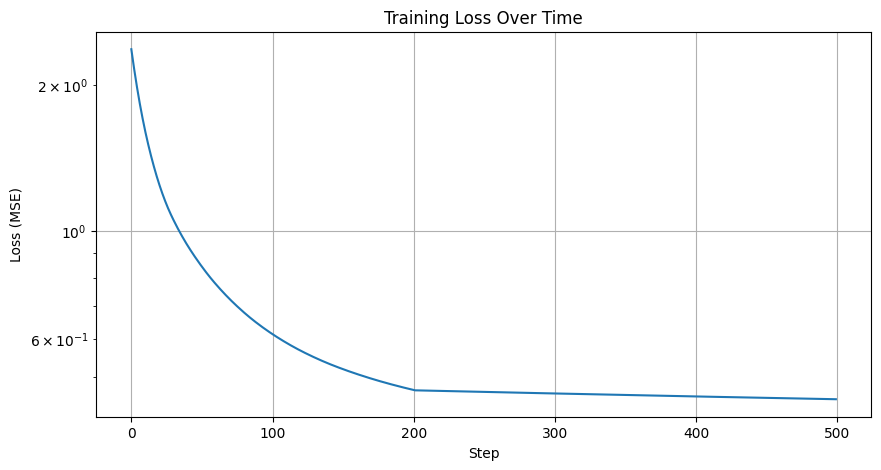


Final weight statistics:
Wh1: min=-1.2774, max=1.2670, mean=-0.0055, std=0.3998
bh1: min=-0.0114, max=0.0088, mean=-0.0009, std=0.0043
Wh2: min=-0.6156, max=0.5616, mean=-0.0022, std=0.1751
bh2: min=-0.0210, max=0.0207, mean=-0.0016, std=0.0088
Wh3: min=-0.7059, max=0.7458, mean=-0.0006, std=0.2588
bh3: min=-0.0299, max=0.0282, mean=-0.0051, std=0.0158
Wo: min=-0.6775, max=0.7113, mean=0.0220, std=0.3514
bo: min=-0.0815, max=-0.0815, mean=-0.0815, std=nan


C:\Users\Mezon\AppData\Local\Temp\ipykernel_19296\78724802.py:16: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\ReduceOps.cpp:1831.)
  print(f"{name}: min={p.data.min():.4f}, max={p.data.max():.4f}, mean={p.data.mean():.4f}, std={p.data.std():.4f}")


In [36]:
import matplotlib.pyplot as plt

# Plot loss history
plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.xlabel('Step')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss Over Time')
plt.grid(True)
plt.yscale('log')  # Log scale to see all values
plt.show()

# Check final weight magnitudes
print("\nFinal weight statistics:")
for name, p in model.named_parameters():
    print(f"{name}: min={p.data.min():.4f}, max={p.data.max():.4f}, mean={p.data.mean():.4f}, std={p.data.std():.4f}")